<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/pytorch/mobilenet-v3-large-cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



# MobileNetV3-Small Classifier on CIFAR-10

This notebook implements MobileNetV3-Large **[1]** and applies it to the CIFAR-10 dataset.

### Network Architecture

![MobileNetV3-Large](https://image2url.com/r2/bucket1/images/1767974870077-824919c0-6c0a-4f88-a28b-6f99812c2a07.png)

[<u>Source</u>](https://arxiv.org/pdf/1905.02244)

---
### **MobileNet-V3**: Bottleneck Block

![mobilenet-v3-bottleneck-block](https://pytorch.org/assets/images/mobilenet-v3-block.png)

[<u>Source</u>](https://pytorch.org/blog/torchvision-mobilenet-v3-implementation/)

---

### MobileNet-V**x**: Backbone Block
| MobileNetV2 | MobileNetV3 |
| :---: | :---: |
| ![mobilenet-V2](https://image2url.com/r2/bucket2/images/1767903528098-a7905c4e-af35-4449-bf8c-45dafc9cdce4.png) <br>[<u>Source</u>](https://arxiv.org/abs/1801.0438/) | ![mobilenet-V3](https://figures.semanticscholar.org/915f986f1edce79cdde3c6ab7d335a7f14db4d2c/2-Figure1-1.png) <br>[<u>Source</u>](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9389905&tag=1) |




---
**REFERENCES:**
1. Howard, M., et al. ["Searching for MobileNetV3."](https://arxiv.org/abs/1905.02244) CVPR, 2018.
2. Johnson, J. (2022, February 2). _Lecture 11: CNN Architectures, Part 2_ [PowerPoint Slides]. University of Michigan EECS 498/598: Deep Learning for Computer Vision. pp 44-53. https://web.eecs.umich.edu/~justincj/slides/eecs498/WI2022/598_WI2022_lecture11.pdf

In [4]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
# Check if GPU is available and set the device
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Num GPUs Available: ", num_gpus)
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("No GPU available.")


Num GPUs Available:  1
GPU 0: Tesla T4


---
# 0. Model Hyperparameters
---

In [7]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 #256
LEARNING_RATE = 0.001
NUM_EPOCHS = 75 #50 #30
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
set_all_seeds(RANDOM_SEED)

---
# 1. Data Preparation & Loading

---
**Notes:**

1. Since we adjust the model to handle the CIFAR images natively, we should remove the `Resize((xx, yy))` from your transforms. It will make ythe training **10x faster** and use significantly less memory.

In [9]:
# CIFAR-10 specific stats (MEAN_arr, STD_arr)
stats = ((0.4914, 0.4822, 0.4465), (0.2471, 0.2435, 0.2616)) #(0.2023, 0.1994, 0.2010))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Standard CIFAR augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [10]:
# Checking the dataset
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    print('Class labels of 10 examples:', labels[:10])
    break

Image batch dimensions: torch.Size([128, 3, 32, 32])
Image label dimensions: torch.Size([128])
Class labels of 10 examples: tensor([2, 7, 4, 7, 0, 1, 1, 6, 9, 2])


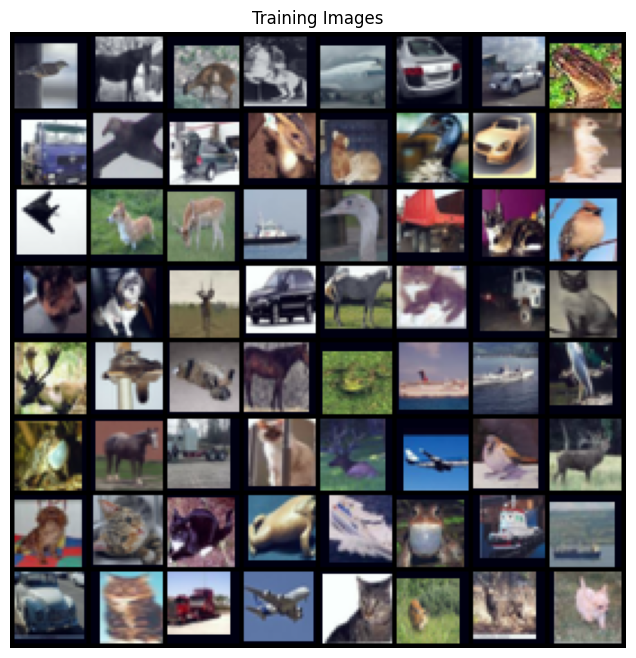

In [11]:
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(torchvision.utils.make_grid(images[:64],
                                         padding=2, normalize=True),
                        (1, 2, 0)))

---
# 2. Model Creation

---
**Notes:**

1. For CIFAR-10, we modify the original architecture by setting the **initial convolution stride to 1** instead of 2. This prevents the $32 \times 32$ image from shrinking too fast.

In [12]:
def _make_divisible(v, divisor, min_value=None):
    """ Ensure all layers have a channel count divisible by 8 """
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

class HSwish(nn.Module):
    """
    Hard-Swish activation: professional fallback implementation.
    """
    def __init__(self, inplace: bool = True):
        super(HSwish, self).__init__()
        self.inplace = inplace

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if hasattr(F, 'hardswish'):
            return F.hardswish(x, inplace=self.inplace)
        return x * F.relu6(x + 3, inplace=self.inplace) / 6

class SqueezeExcitation(nn.Module):
    """
    SE Block: Learns to weight channels based on their importance.
    """
    def __init__(self, in_channels, reduction=4):
        super(SqueezeExcitation, self).__init__()
        # Ensure channel counts are divisible by 8 for hardware efficiency
        squeeze_channels = _make_divisible(in_channels // reduction, 8)

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, squeeze_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(squeeze_channels, in_channels, kernel_size=1),
            nn.Hardsigmoid(inplace=True)
        )

    def forward(self, x):
        return x * self.se(x)

class Block(nn.Module):
    def __init__(self, kernel_size, in_channels, expand_size, out_channels, se, nl, stride):
        super().__init__()
        self.stride = stride
        self.use_se = se
        self.use_res_connect = self.stride == 1 and in_channels == out_channels

        activation = HSwish if nl == 'HS' else nn.ReLU

        # Expansion
        self.conv1 = nn.Conv2d(in_channels, expand_size, 1, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(expand_size)
        self.act1 = activation(inplace=True)

        # Depthwise
        self.conv2 = nn.Conv2d(expand_size, expand_size, kernel_size, stride, kernel_size//2, groups=expand_size, bias=False)
        self.bn2 = nn.BatchNorm2d(expand_size)
        self.act2 = activation(inplace=True)

        # SE Block
        self.se = SqueezeExcitation(expand_size) if se else nn.Identity()

        # Projection (Linear)
        self.conv3 = nn.Conv2d(expand_size, out_channels, 1, 1, 0, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.act2(self.bn2(self.conv2(out)))
        out = self.se(out)
        out = self.bn3(self.conv3(out))

        if self.use_res_connect:
            return x + out
        return out

class MobileNetV3_Large(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Configuration for Large: [kernel, expansion, out_channels, use_se, activation, stride]
        # Based on the official MobileNetV3 paper
        self.config = [
            [3, 16,  16,  False, 'RE', 1],
            [3, 64,  24,  False, 'RE', 2],
            [3, 72,  24,  False, 'RE', 1],
            [5, 72,  40,  True,  'RE', 2],
            [5, 120, 40,  True,  'RE', 1],
            [5, 120, 40,  True,  'RE', 1],
            [3, 240, 80,  False, 'HS', 2],
            [3, 200, 80,  False, 'HS', 1],
            [3, 184, 80,  False, 'HS', 1],
            [3, 184, 80,  False, 'HS', 1],
            [3, 480, 112, True,  'HS', 1],
            [3, 672, 112, True,  'HS', 1],
            [5, 672, 160, True,  'HS', 2],
            [5, 960, 160, True,  'HS', 1],
            [5, 960, 160, True,  'HS', 1],
        ]

        # First Layer: Stride 1 for CIFAR-10 (originally 2 in ImageNet)
        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.act1 = HSwish(inplace=True)

        # Build Blocks
        layers = []
        in_channels = 16
        for k, exp, out, se, nl, s in self.config:
            # Use _make_divisible for hardware-optimized channel counts
            exp_ch = _make_divisible(exp, 8)
            out_ch = _make_divisible(out, 8)

            layers.append(Block(k, in_channels, exp_ch, out_ch, se, nl, s))
            in_channels = out_ch

        self.blocks = nn.Sequential(*layers)

        # Final Feature Layers
        last_out = 960
        self.conv2 = nn.Conv2d(in_channels, last_out, 1, 1, 0, bias=False)
        self.bn2 = nn.BatchNorm2d(last_out)
        self.act2 = HSwish(inplace=True)

        # Global Average Pooling and Classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(last_out, 1280),
            HSwish(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.act1(self.bn1(self.conv1(x)))
        x = self.blocks(x)
        x = self.act2(self.bn2(self.conv2(x)))
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [13]:
model = MobileNetV3_Large().to(device)

In [14]:
# Model parameter details
summary(model,
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE),
        # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
MobileNetV3_Large                                  [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Conv2d: 1-1                                      [128, 3, 32, 32]          [128, 16, 32, 32]         432                       [3, 3]                    56,623,104
├─BatchNorm2d: 1-2                                 [128, 16, 32, 32]         [128, 16, 32, 32]         32                        --                        4,096
├─HSwish: 1-3                                      [128, 16, 32, 32]         [128, 16, 32, 32]         --                        --                        --
├─Sequential: 1-4                                  [128, 16, 32, 32]         [128, 160, 2, 2]          --                        --                        --
│    └─Block: 2-1                 

---
# 3. Model Training, Testing & Evaluation

---

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
# optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4) # Use weight decay (L2) to combat overfitting
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_subset)
    train_acc = calculate_accuracy(train_loader)

    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_subset)
    val_acc = calculate_accuracy(val_loader)

    # scheduler.step(val_loss)
    # current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    # history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          # f'LR: {current_lr:.8f}')
         )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/75 | Train Loss: 1.74394, Train Acc.: 43.97% | Val Loss: 1.53586, Val Acc.: 42.32% | 
Epoch 2/75 | Train Loss: 1.38070, Train Acc.: 54.22% | Val Loss: 1.28692, Val Acc.: 53.92% | 
Epoch 3/75 | Train Loss: 1.18384, Train Acc.: 60.54% | Val Loss: 1.13871, Val Acc.: 58.88% | 
Epoch 4/75 | Train Loss: 1.04309, Train Acc.: 64.41% | Val Loss: 1.00583, Val Acc.: 62.24% | 
Epoch 5/75 | Train Loss: 0.94883, Train Acc.: 66.10% | Val Loss: 0.98264, Val Acc.: 64.38% | 
Epoch 6/75 | Train Loss: 0.86432, Train Acc.: 70.38% | Val Loss: 0.88011, Val Acc.: 69.02% | 
Epoch 7/75 | Train Loss: 0.80810, Train Acc.: 74.01% | Val Loss: 0.79819, Val Acc.: 72.28% | 
Epoch 8/75 | Train Loss: 0.75617, Train Acc.: 74.98% | Val Loss: 0.75979, Val Acc.: 73.46% | 
Epoch 9/75 | Train Loss: 0.71642, Train Acc.: 77.57% | Val Loss: 0.69830, Val Acc.: 75.90% | 
Epoch 10/75 | Train Loss: 0.68651, Train Acc.: 77.34% | Val Loss: 0.70304, Val Acc.: 75.24% | 
Epoch 11/75 | Train Loss: 0.65

In [16]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

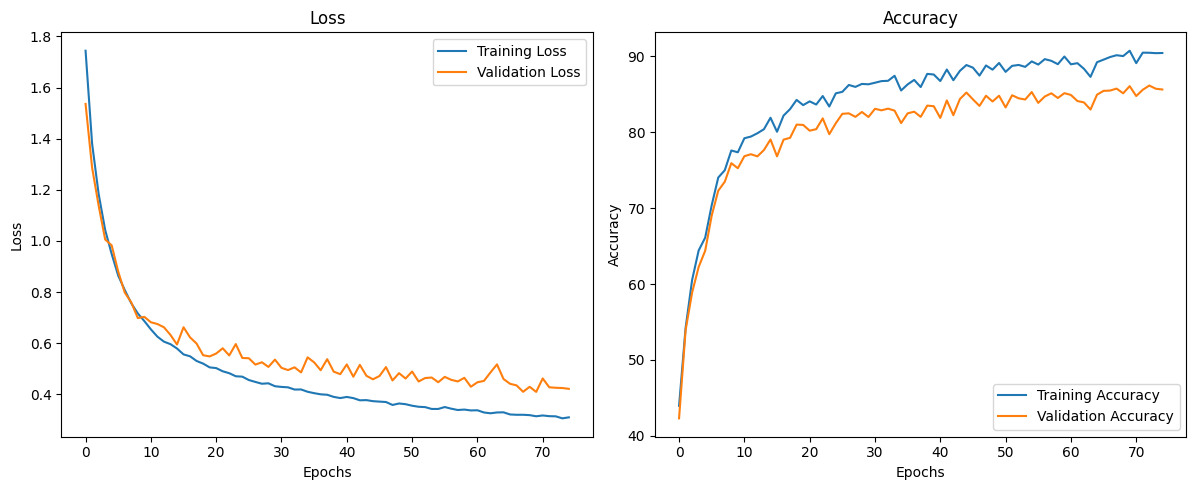

In [17]:
plot_history(history)

In [18]:
class_dict = {0: 'plane',
              1: 'car',
              2: 'bird',
              3: 'cat',
              4: 'deer',
              5: 'dog',
              6: 'frog',
              7: 'horse',
              8: 'ship',
              9: 'truck'}

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def _compute_confusion_matrix(model, data_loader, device):
    """
    Computes a confusion matrix for the given model and data.
    Uses scikit-learn for robustness and speed.
    """
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            # Move to CPU and convert to list/numpy immediately
            all_targets.extend(targets.view(-1).cpu().numpy())
            all_predictions.extend(predicted_labels.view(-1).cpu().numpy())

    return confusion_matrix(all_targets, all_predictions)

def _plot_confusion_matrix(mat, class_names):
    """
    Visualizes the confusion matrix using Seaborn for professional reporting.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: MobileNetV2 on CIFAR-10')
    plt.show()

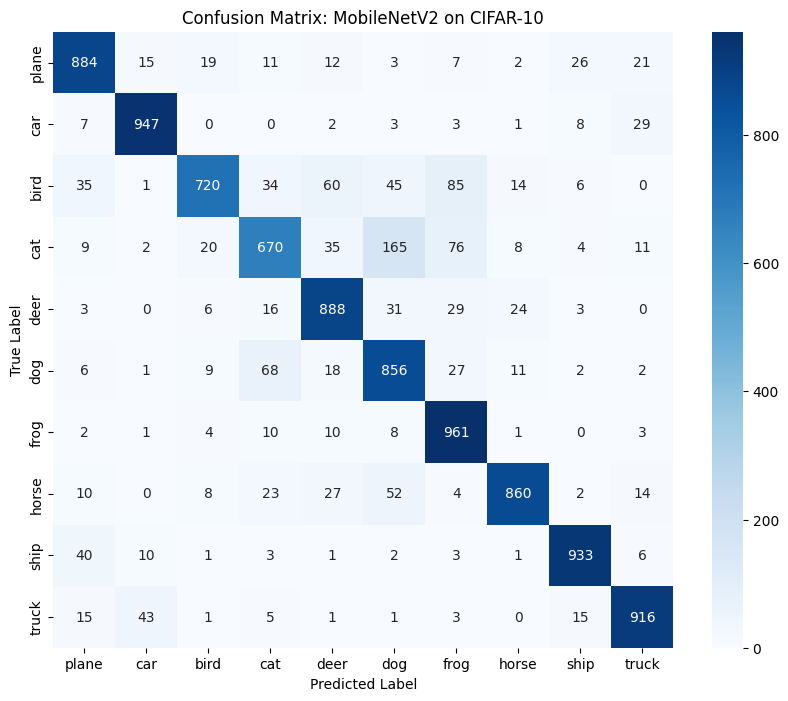

In [20]:
_mat = _compute_confusion_matrix(model=model, data_loader=test_loader, device=device)
_plot_confusion_matrix(_mat, class_names=class_dict.values())

In [21]:
%watermark -iv

matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

